In [1]:
import sys
import os

# Absolute path to the parent directory that contains `gspn`
parent_dir = os.path.abspath(os.path.dirname(os.getcwd()))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# Now try importing the package again
import gspn

ModuleNotFoundError: No module named 'gspn'

In [ ]:
import gspn
from copy import copy
from pprint import pprint

In [ ]:
import sys
print(sys.version)

In [ ]:
# Define Places and Transitions
p = {
            'P10': 1,  # Start with 1 token in P1
            'P11': 0,  # Start with 1 token in P2
            'P12': 0,
            'P13': 0,
            'P20': 1,
            'P21': 0,
            'P22': 0,
            'P23': 0,
            'M1': 1,
            'M2': 1,
            'M3': 1,
        }

t = {       
            'O11': {'type': 'stochastic', 
                    'distribution': 'exponential',
                    'params': {'rate': 1/2}, 
                    'input': ['P11', 'M1'], 
                    'output': ['P12', 'M1']},
            'O12': {'type': 'stochastic',
                    'distribution': 'exponential',
                    'params': {'rate': 1/4},
                    'input': ['P12', 'M2'], 
                    'output': ['P13', 'M2']},
            'O13': {'type': 'stochastic',
                    'distribution': 'exponential',
                    'params': {'rate': 1/3},
                    'input': ['P10', 'M3'], 
                    'output': ['P11', 'M3']},
            'O21': {'type': 'stochastic',
                    'distribution': 'exponential',
                    'params': {'rate': 1/5},
                    'input': ['P22', 'M1'], 
                    'output': ['P23', 'M1']},
            'O22': {'type': 'stochastic',
                    'distribution': 'exponential',
                    'params': {'rate': 1/2}, 
                    'input': ['P20', 'M2'], 
                    'output': ['P21', 'M2']},
            'O23': {'type': 'stochastic',
                    'distribution': 'exponential',
                    'params': {'rate': 1/3},
                    'input': ['P21', 'M3'], 
                    'output': ['P22', 'M3']},
        }

In [ ]:
import gspn4py
from gspn4py import simulator

n_iterations = 10000
results = []
makespan = [None] * n_iterations

for i in range(n_iterations):
    print(f"\nIteration {i + 1}:")
    firing_sequence = simulator.run_gspn_simulation(places=copy(p), transitions=copy(t))
    makespan[i] = list(firing_sequence.items())[-1][1]
    results.append(firing_sequence)


makespan = [x-2 for x in makespan]
makespan = [x for x in makespan if x >= 0]


with open(f'makespan_data.txt', 'w') as f:
    for value in makespan:
        f.write(f'{value}\n')

# np.savetxt('data.txt', data)


import numpy as np
data = np.loadtxt('makespan_data.txt')
mu = np.mean(data)
sigma = np.std(data)
N = len(data)
binwidth = (data.max() - data.min()) / 100  # for 10 bins

print(N)
print(binwidth)

In [ ]:
import numpy as np
import os
from pprint import pprint


WEATHER_DATA_PATH = f"/home/peng-luh/__github/proj_l3s_offshore_2/WEATHER_DATA/weatherdata.npy"

data = np.load(WEATHER_DATA_PATH)

wind = data[0]
wave = data[1]


In [ ]:
import os

cwd = os.getcwd()
print(cwd)

from pathlib import Path

cwd = Path.cwd()       # Returns Path('maindir/subdir')
parent_dir = cwd.parent   # Returns Path('maindir')
print(parent_dir)

In [ ]:
%reset -f
from gspn4py.offshoreplan.offshore_utils import generate_markoff, get_prob, get_duration_owt_markoff, get_operation_duration_markov
import numpy as np
from datetime import datetime
from dateutil import parser

# WEATHER_DATA_PATH = f"/home/peng-luh/__github/proj_l3s_offshore_2/WEATHER_DATA/weatherdata.npy"

# weather_data = np.load(WEATHER_DATA_PATH)
# print(weather_data.shape)
T = 84
P = 2
N = 1

# current_date = datetime.strptime("2000-04-01-08", '%Y-%m-%d-%H')

job_duration = [2]
job_requirements = np.column_stack([10.0, 2.0])
current_date = "2000-04-01-08"


estimated_duration = get_operation_duration_markov(current_date=current_date, job_duration=job_duration, job_requirements=job_requirements)
print(estimated_duration)

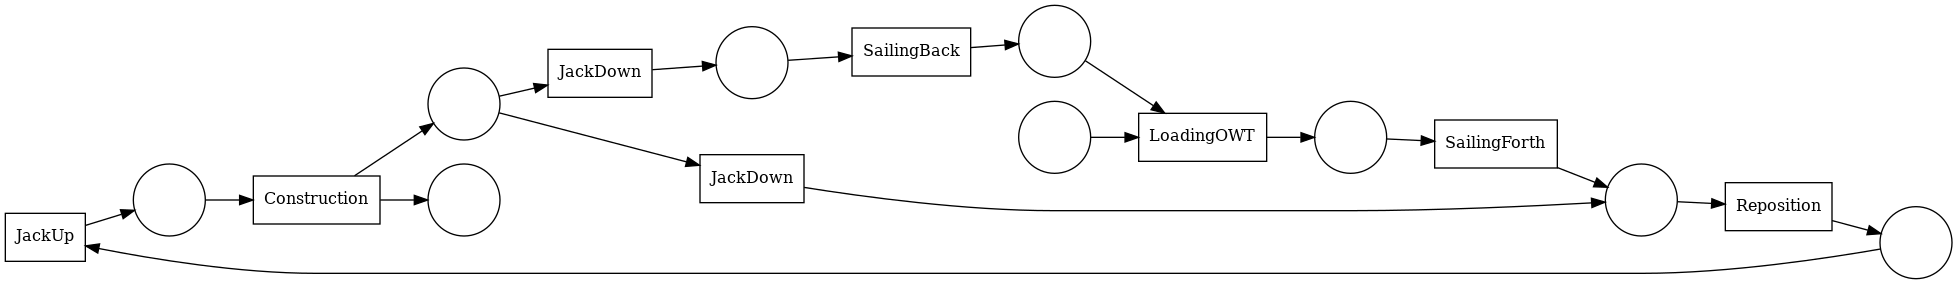

Number of enabled ts: 1
Number of enabled ts: 0
duration: 12
0
{}
None


TypeError: Parser must be a string or character stream, not int

In [ ]:
%reset -f

from gspn4py import TimedPetriNet, OffshoreSimulator

import pm4py
from pm4py import Marking
from gspn4py.utils import import_pndf_from_json
from pprint import pprint

pndf = import_pndf_from_json(json_file_path="../models/offshore_models/full_cyclic_model.json")


pn = TimedPetriNet()


r = pn.build_from_pndf(pndf_json=pndf)
pm4py.view_petri_net(pn, pn.initial_marking, pn.final_marking)

meta_data = {
    "sim_usesHistoricalWeather": -1,
    "T": 84,
    "P": 2,
    "N": 168,
    "pn_deltaTime": 1,
    "pn_maxWaitTime": 96,
    "pn_fairMode": 1,
    "pn_pruningFlag": 2,
    "pn_tau": 0.01,
    "pn_searchSpace": 0,
    "scenario_simulationStartDate": "15-Jun-2000",
}

timed_simulator = OffshoreSimulator(timed_petri_net=pn, properties=meta_data)
timed_simulator.run()

pprint(timed_simulator.get_sim_results())
